<a href="https://colab.research.google.com/github/Omar2023K/Udemy-Project/blob/main/car_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Car Price Prediction project**




## In this project, we aim to perform a comprehensive analysis of used car prices to understand the factors that influence vehicle pricing and to predict the price of a car based on its features. We will leverage data from a dataset containing several key attributes of cars, and through detailed analysis, we will identify trends, correlations, and patterns in the data. Additionally, we will build predictive models to estimate the selling price of a used car based on various factors such as car specifications, condition, and other related features.

# **Feature Exploration:-**


1.   Car Name : The model name or variant of the car.
2.   Year : The year of manufacture.
3.   Selling_price : This is the target variable in our analysis.
4.   Kilometers Driven : Indicates how much this car has driven.
5.   Fuel Type : Fuel type (Diesel, Petrol)
6.   Seller Type: Whether the car is being sold by an individual or a dealer.
7.   Transmission : Manual or automatic.
8.   Owner History : The number of previous owners.
9.   Mileage : refers to the number of kilometers a vehicle can travel per unit.
10.  Engine Size : The engine capacity (in cc).
11.  Max Power : the maximum power output of a vehicle’s engine.
12.  Torque : is a measure of the rotational force produced by an engine.
13.  The number of seats.




In [ ]:
pip install ydata-profiling


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.1/686.1 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 52.8 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=3b50f1b253c84f2bd07625c5ac30fce9a91cbe69b8837fab1e66638f0f364830
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, explained_variance_score,accuracy_score



In [ ]:
df = pd.read_csv('/content/reg_cars_selling.csv')

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:

df.shape

(8128, 13)

In [ ]:
df.columns

Index(['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'mileage', 'engine', 'max_power', 'torque',
       'seats'],
      dtype='object')

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
ProfileReport(df)

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# **Check missing values**

In [ ]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [ ]:
df[df.isna().any(axis=1)].sample(30)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
2291,Maruti Omni E 8 Str STD,2005,120000,100000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
3154,Mahindra Bolero LX,2006,210000,120000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN
2105,Tata Sumo EX BS IV,2012,254999,190000,Diesel,Individual,Manual,Third Owner,NaN,NaN,NaN,NaN,NaN
5447,Maruti Swift 1.3 ZXI,2008,200000,90000,Petrol,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN
7581,Maruti Swift 1.3 ZXI,2006,229999,110000,Petrol,Individual,Manual,Third Owner,NaN,NaN,NaN,NaN,NaN
2464,Maruti Omni E 8 Str STD,2005,105000,59635,Petrol,Dealer,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
4254,Maruti Swift VDI BSIV,2009,210000,120000,Diesel,Individual,Manual,Fourth & Above Owner,NaN,NaN,NaN,NaN,NaN
3699,Toyota Etios Liva GD SP,2012,315000,100000,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN,NaN
6934,Tata Indica Vista Aqua 1.3 Quadrajet (ABS),2012,250000,100000,Diesel,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN
4056,Hyundai Santro Xing XL,2007,200000,120000,Petrol,Individual,Manual,Second Owner,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


In [ ]:
df.shape

(7906, 13)

# **check duplicate values**




In [ ]:
df.duplicated().sum()

1189

In [ ]:
df[df.duplicated(keep='first')]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
291,Hyundai Grand i10 Sportz,2017,450000,35000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,82 bhp,114Nm@ 4000rpm,5.0
296,Maruti Swift VXI,2012,330000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,85.8 bhp,114Nm@ 4000rpm,5.0
370,Jaguar XE 2016-2019 2.0L Diesel Prestige,2017,2625000,9000,Diesel,Dealer,Automatic,First Owner,13.6 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
371,Lexus ES 300h,2019,5150000,20000,Petrol,Dealer,Automatic,First Owner,22.37 kmpl,2487 CC,214.56 bhp,202Nm@ 3600-5200rpm,5.0
372,Jaguar XF 2.0 Diesel Portfolio,2017,3200000,45000,Diesel,Dealer,Automatic,First Owner,19.33 kmpl,1999 CC,177 bhp,430Nm@ 1750-2500rpm,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7987,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37 kmpl,1461 CC,108.45 bhp,240Nm@ 1750rpm,5.0
7988,Maruti Ciaz Alpha Diesel,2019,1025000,32000,Diesel,Individual,Manual,First Owner,28.09 kmpl,1248 CC,88.50 bhp,200Nm@ 1750rpm,5.0
8117,Maruti Swift Dzire VDI,2015,625000,50000,Diesel,Individual,Manual,First Owner,26.59 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
8126,Tata Indigo CR4,2013,290000,25000,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm,5.0


In [ ]:
df.drop_duplicates(keep='first',inplace=True)

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6717 non-null   object 
 1   year           6717 non-null   int64  
 2   selling_price  6717 non-null   int64  
 3   km_driven      6717 non-null   int64  
 4   fuel           6717 non-null   object 
 5   seller_type    6717 non-null   object 
 6   transmission   6717 non-null   object 
 7   owner          6717 non-null   object 
 8   mileage        6717 non-null   object 
 9   engine         6717 non-null   object 
 10  max_power      6717 non-null   object 
 11  torque         6717 non-null   object 
 12  seats          6717 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 734.7+ KB


# **Data preprossing**

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [ ]:
df['mileage'] = df['mileage'].str.replace('kmpl','')

In [ ]:
df['engine'] = df['engine'].str.replace('CC','')

In [ ]:
df['max_power'] = df['max_power'].str.replace('bhp','')

In [ ]:
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248,74,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7,1497,78,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0,1396,90,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1,1298,88.2,"11.5@ 4,500(kgm@ rpm)",5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8121,Maruti Wagon R VXI BS IV with ABS,2013,260000,50000,Petrol,Individual,Manual,Second Owner,18.9,998,67.1,90Nm@ 3500rpm,5.0
8122,Hyundai i20 Magna 1.4 CRDi,2014,475000,80000,Diesel,Individual,Manual,Second Owner,22.54,1396,88.73,219.7Nm@ 1500-2750rpm,5.0
8123,Hyundai i20 Magna,2013,320000,110000,Petrol,Individual,Manual,First Owner,18.5,1197,82.85,113.7Nm@ 4000rpm,5.0
8124,Hyundai Verna CRDi SX,2007,135000,119000,Diesel,Individual,Manual,Fourth & Above Owner,16.8,1493,110,"24@ 1,900-2,750(kgm@ rpm)",5.0


In [ ]:
df[['torque_value', 'rpm']] = df['torque'].str.extract(r'(\d+\.?\d*)(?:Nm|kgm)?.*?@\s?([\d,-]+)')

In [ ]:
df['torque_value'].isna().sum()

224

In [ ]:
df[df['torque_value'].isna()]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,torque_value,rpm
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0,1396,90,22.4 kgm at 1750-2750rpm,5.0,NaN,NaN
17,Hyundai i20 1.4 CRDi Asta,2012,500000,53000,Diesel,Individual,Manual,Second Owner,23.0,1396,90,22.4 kgm at 1750-2750rpm,5.0,NaN,NaN
109,Tata Indica Vista Aura 1.2 Safire (ABS) BS IV,2010,300000,48000,Petrol,Individual,Manual,First Owner,15.8,1172,65,96 Nm at 3000 rpm,5.0,NaN,NaN
145,Volvo XC40 D4 R-Design,2018,3400000,22000,Diesel,Dealer,Automatic,First Owner,18.0,1969,190,400Nm,5.0,NaN,NaN
149,BMW 5 Series 523i,2010,975000,72200,Petrol,Dealer,Automatic,Second Owner,10.8,2497,150,250 Nm at 2750 rpm,5.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7759,Honda City 1.5 S MT,2017,675000,49523,Petrol,Dealer,Manual,First Owner,17.0,1497,118,146Nm at 4800 rpm,5.0,NaN,NaN
7810,Tata Indica Vista Aqua TDI BSIII,2011,200000,200000,Diesel,Individual,Manual,Second Owner,17.0,1405,71,135 Nm at 2500 rpm,5.0,NaN,NaN
7930,Volvo S90 D4 Inscription BSIV,2019,5500000,17000,Diesel,Individual,Automatic,First Owner,18.0,1969,190,400Nm,5.0,NaN,NaN
8032,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5,1172,65,96 Nm at 3000 rpm,5.0,NaN,NaN


In [ ]:
df['torque_value'].astype(float)

,torque_value
0,190.0
1,250.0
2,12.7
3,NaN
4,11.5
...,...
8121,90.0
8122,219.7
8123,113.7
8124,24.0


In [ ]:
df['torque_value'] = pd.to_numeric(df['torque_value'], errors='coerce')

In [ ]:
df['torque_value'].max()

789.0

In [ ]:
df.isna().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,0
engine,0


In [ ]:
df['torque_value'].fillna(df['torque_value'].mode()[0], inplace=True)

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,torque_value,rpm
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248,74,190Nm@ 2000rpm,5.0,190.0,2000
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,250Nm@ 1500-2500rpm,5.0,250.0,1500-2500
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7,1497,78,"12.7@ 2,700(kgm@ rpm)",5.0,12.7,"2,700"
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0,1396,90,22.4 kgm at 1750-2750rpm,5.0,200.0,NaN
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1,1298,88.2,"11.5@ 4,500(kgm@ rpm)",5.0,11.5,"4,500"


In [ ]:
df.drop(columns=['rpm','torque'], inplace=True)

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,torque_value
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248,74,5.0,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5.0,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7,1497,78,5.0,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0,1396,90,5.0,200.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1,1298,88.2,5.0,11.5


In [ ]:
df.rename(columns={'torque_value':'Torque'},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6717 non-null   object 
 1   year           6717 non-null   int64  
 2   selling_price  6717 non-null   int64  
 3   km_driven      6717 non-null   int64  
 4   fuel           6717 non-null   object 
 5   seller_type    6717 non-null   object 
 6   transmission   6717 non-null   object 
 7   owner          6717 non-null   object 
 8   mileage        6717 non-null   object 
 9   engine         6717 non-null   object 
 10  max_power      6717 non-null   object 
 11  seats          6717 non-null   float64
 12  Torque         6717 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 734.7+ KB


# **Outliers**

In [ ]:
Q1 = df['selling_price'].quantile(0.25)
Q3 = df['selling_price'].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [ ]:
df[(df['selling_price'] < lower_bound) ]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Torque


In [ ]:
df[(df['selling_price'] > upper_bound) ]

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Torque
41,Jeep Compass 1.4 Limited Plus BSIV,2019,2100000,5000,Petrol,Individual,Automatic,First Owner,16.0,1368,160.77,5.0,250.0
47,Toyota Fortuner 4x4 MT,2014,1500000,77000,Diesel,Dealer,Manual,First Owner,12.55,2982,168.5,7.0,343.0
49,Mercedes-Benz B Class B180,2014,1450000,27800,Diesel,Dealer,Automatic,Second Owner,14.8,2143,120.7,5.0,200.0
55,Toyota Innova Crysta 2.8 ZX AT BSIV,2016,1650000,127700,Diesel,Dealer,Automatic,Second Owner,11.36,2755,171.5,7.0,360.0
57,Audi A6 2.0 TDI Technology,2013,1750000,33900,Diesel,Dealer,Automatic,Second Owner,17.68,1968,174.33,5.0,380.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7949,Toyota Innova 2.5 ZX Diesel 7 Seater BSIII,2015,1400000,170000,Diesel,Individual,Manual,First Owner,12.99,2494,100.6,7.0,200.0
7963,Renault Captur 1.5 Diesel RXT,2018,1265000,12000,Diesel,Individual,Manual,First Owner,20.37,1461,108.45,5.0,240.0
7967,BMW 3 Series 320d Sedan,2011,1500000,84925,Diesel,Individual,Automatic,First Owner,16.07,1995,181,5.0,380.0
8058,Audi A3 40 TFSI Premium,2017,1689999,8000,Petrol,Dealer,Automatic,First Owner,16.6,1798,177.5,5.0,250.0


In [ ]:
max_price_index = df['selling_price'].idxmax()

In [ ]:
df.loc[max_price_index]

,170
name,Volvo XC90 T8 Excellence BSIV
year,2017
selling_price,10000000
km_driven,30000
fuel,Petrol
seller_type,Individual
transmission,Automatic
owner,First Owner
mileage,42.0
engine,1969


# **Exploratory Data Analysis**

In [ ]:
df['mileage'].value_counts()

,count
mileage,
18.9,210
19.7,168
18.6,150
21.1,146
17.0,124
...,...
12.5,1
14.5,1
16.34,1


In [ ]:
df['name'].value_counts()

,count
name,
Maruti Swift Dzire VDI,118
Maruti Alto 800 LXI,76
Maruti Alto LXi,69
Maruti Swift VDI,60
Maruti Alto K10 VXI,47
...,...
BMW X7 xDrive 30d DPE,1
Skoda Superb Elegance 1.8 TSI AT,1
Skoda Fabia 1.2 TDI Ambition Plus,1


In [ ]:
df['name'].nunique()

1982

In [ ]:
df['year'].value_counts()

,count
year,
2017,802
2016,691
2015,680
2018,607
2014,580
2012,576
2013,560
2011,535
2010,361


In [ ]:
df['selling_price'].value_counts()

,count
selling_price,
300000,208
350000,196
600000,167
400000,164
250000,161
...,...
426000,1
358000,1
348000,1


In [ ]:
df['fuel'].value_counts()

,count
fuel,
Diesel,3658
Petrol,2973
CNG,51
LPG,35


In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Torque
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248,74,5.0,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5.0,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7,1497,78,5.0,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0,1396,90,5.0,200.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1,1298,88.2,5.0,11.5


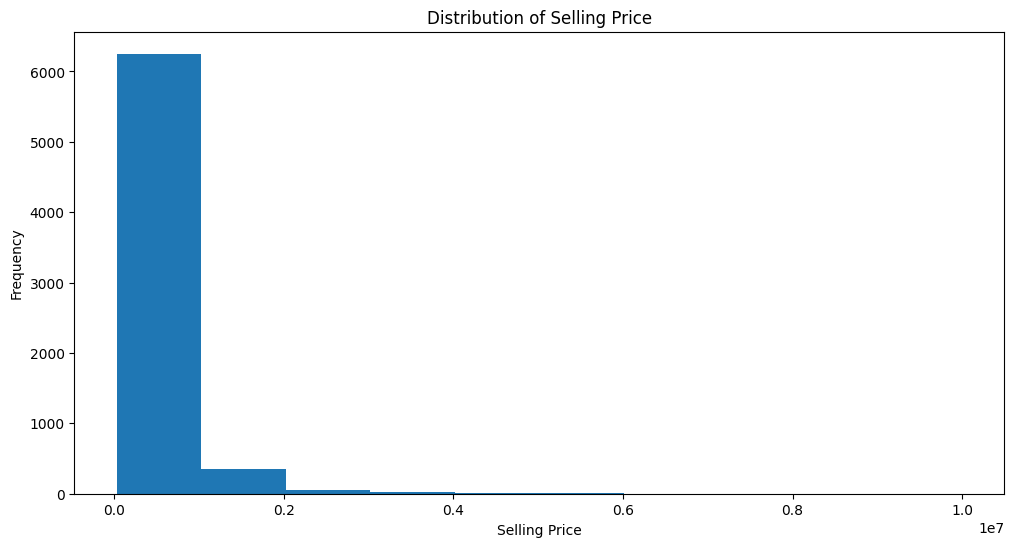

In [ ]:
# What is the distribution of the selling_price

plt.figure(figsize=(12, 6))
plt.hist(df['selling_price'])
plt.title('Distribution of Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

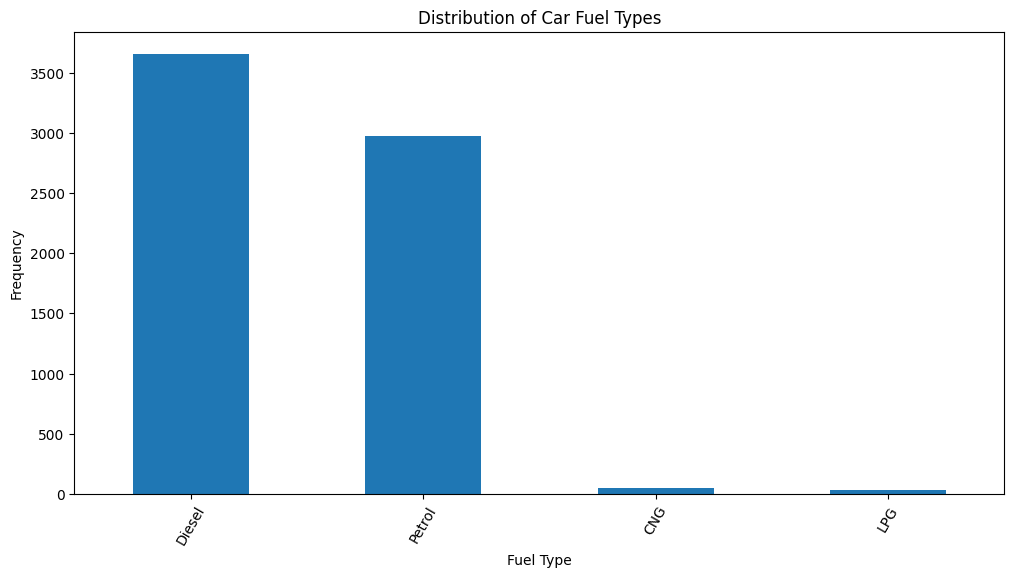

In [ ]:
# What is the distribution of car fuel types

plt.figure(figsize=(12, 6))
df['fuel'].value_counts().plot(kind='bar')
plt.title('Distribution of Car Fuel Types')
plt.xlabel('Fuel Type')
plt.ylabel('Frequency')
plt.xticks(rotation=60)
plt.show()

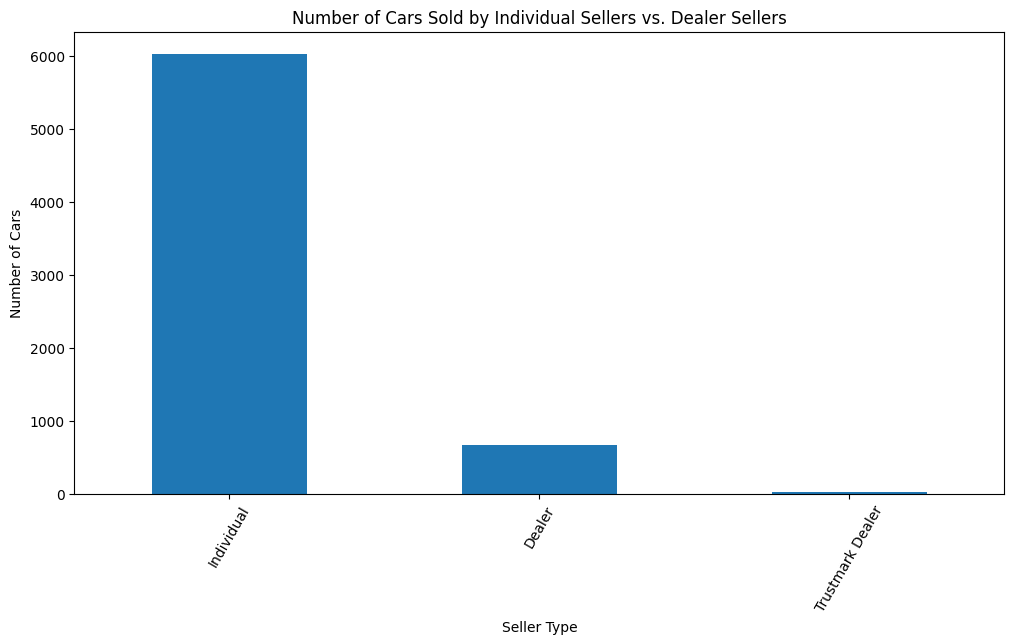

In [ ]:
# How many cars are sold by Individual sellers compared to Dealer sellers (seller_type)?

plt.figure(figsize=(12, 6))
df['seller_type'].value_counts().plot(kind='bar')
plt.title('Number of Cars Sold by Individual Sellers vs. Dealer Sellers')
plt.xlabel('Seller Type')
plt.ylabel('Number of Cars')
plt.xticks(rotation=60)
plt.show()

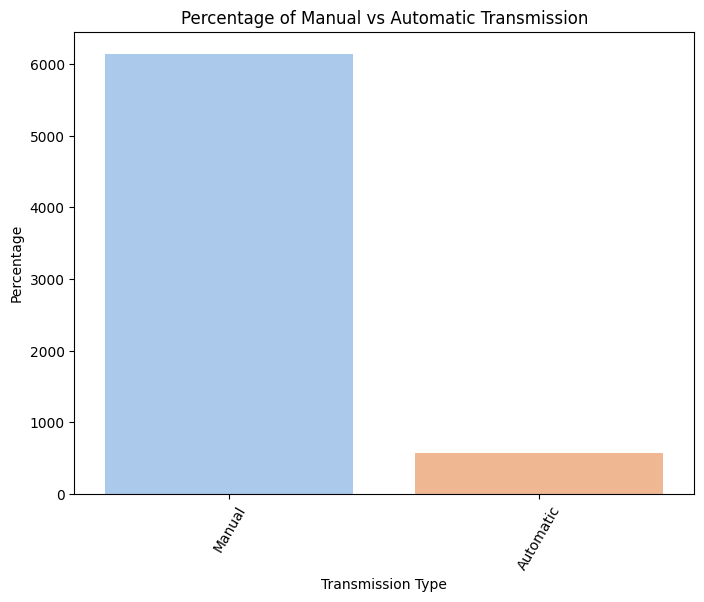

In [ ]:
# What percentage of cars have Manual vs. Automatic transmission?

plt.figure(figsize=(8, 6))
sns.barplot(x=df['transmission'].value_counts().index, y=df['transmission'].value_counts().values, palette='pastel')
plt.title('Percentage of Manual vs Automatic Transmission')
plt.xlabel('Transmission Type')
plt.ylabel('Percentage')
plt.xticks(rotation=60)
plt.show()

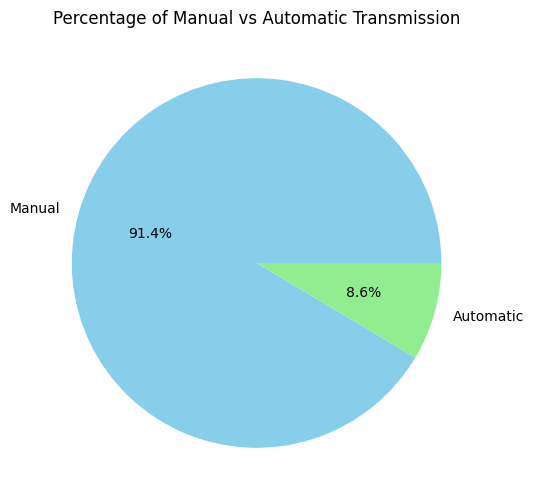

In [ ]:
transmission_percentages = df['transmission'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 6))
transmission_percentages.plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen'], labels=transmission_percentages.index)
plt.title('Percentage of Manual vs Automatic Transmission')
plt.ylabel('')  # Remove y-axis label for better appearance
plt.show()

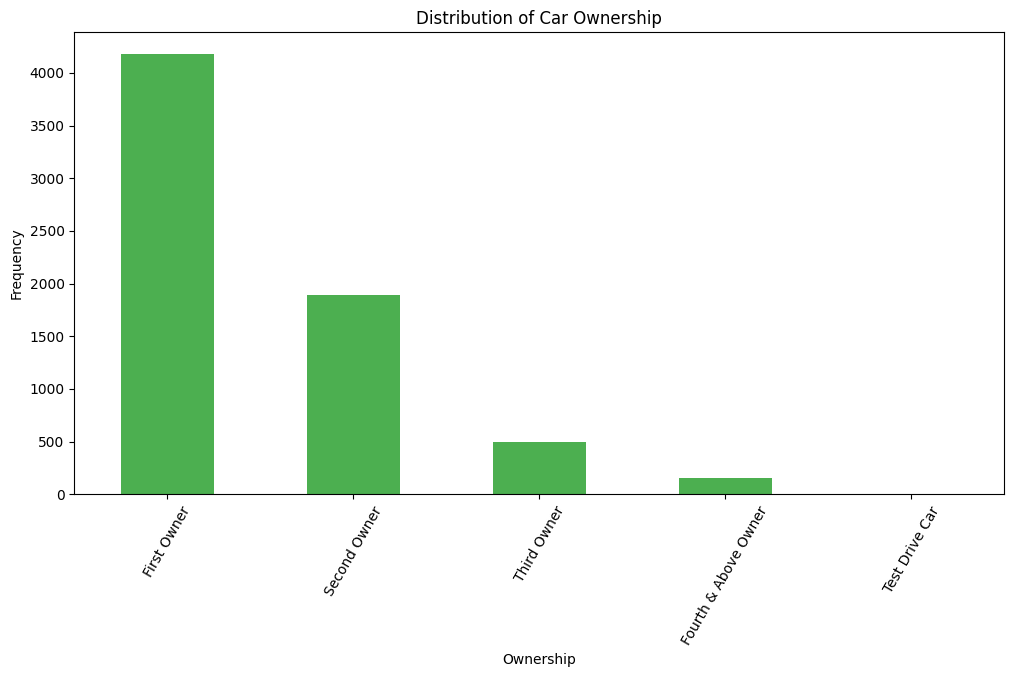

In [ ]:
# What is the distribution of car ownership

plt.figure(figsize=(12, 6))
df['owner'].value_counts().plot(kind='bar',color = "#4CAF50")
plt.title('Distribution of Car Ownership')
plt.xlabel('Ownership')
plt.ylabel('Frequency')
plt.xticks(rotation=60)
plt.show()

<Axes: xlabel='km_driven', ylabel='selling_price'>

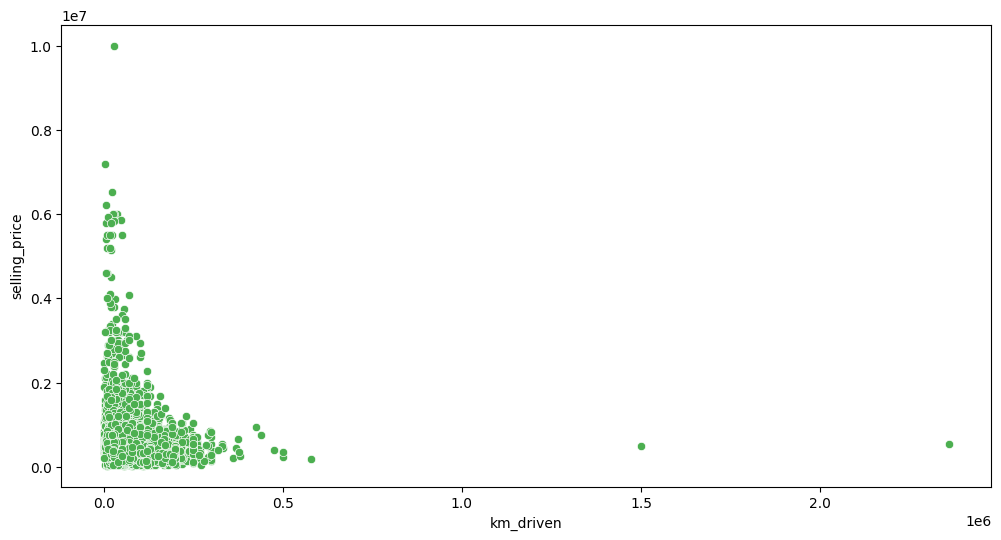

In [ ]:
# How does km_driven affect selling_price?

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['km_driven'], y=df['selling_price'],color = "#4CAF50")

In [ ]:
df_corr = df[['selling_price','km_driven','mileage','engine','max_power','Torque']]

In [ ]:
df_corr = df_corr.apply(pd.to_numeric, errors='coerce')


In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Torque
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4,1248,74,5.0,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5.0,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7,1497,78,5.0,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0,1396,90,5.0,200.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1,1298,88.2,5.0,11.5


In [ ]:
df[['max_power','engine']] = df[['max_power','engine']].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6717 entries, 0 to 8125
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6717 non-null   object 
 1   year           6717 non-null   int64  
 2   selling_price  6717 non-null   int64  
 3   km_driven      6717 non-null   int64  
 4   fuel           6717 non-null   object 
 5   seller_type    6717 non-null   object 
 6   transmission   6717 non-null   object 
 7   owner          6717 non-null   object 
 8   mileage        6717 non-null   object 
 9   engine         6717 non-null   float64
 10  max_power      6717 non-null   float64
 11  seats          6717 non-null   float64
 12  Torque         6717 non-null   float64
dtypes: float64(4), int64(3), object(6)
memory usage: 992.7+ KB


In [ ]:
df['mileage'] = df['mileage'].str.replace('km/kg','').astype(float)

<Axes: xlabel='engine', ylabel='selling_price'>

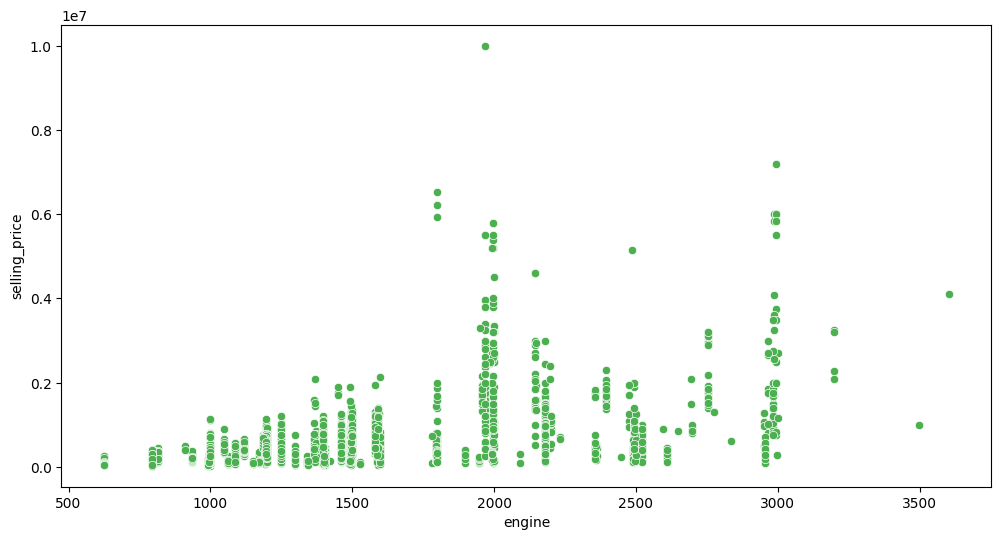

In [ ]:
# What is the relationship between engine size and selling_price?

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['engine'], y=df['selling_price'],color = "#4CAF50")

<Axes: xlabel='max_power', ylabel='selling_price'>

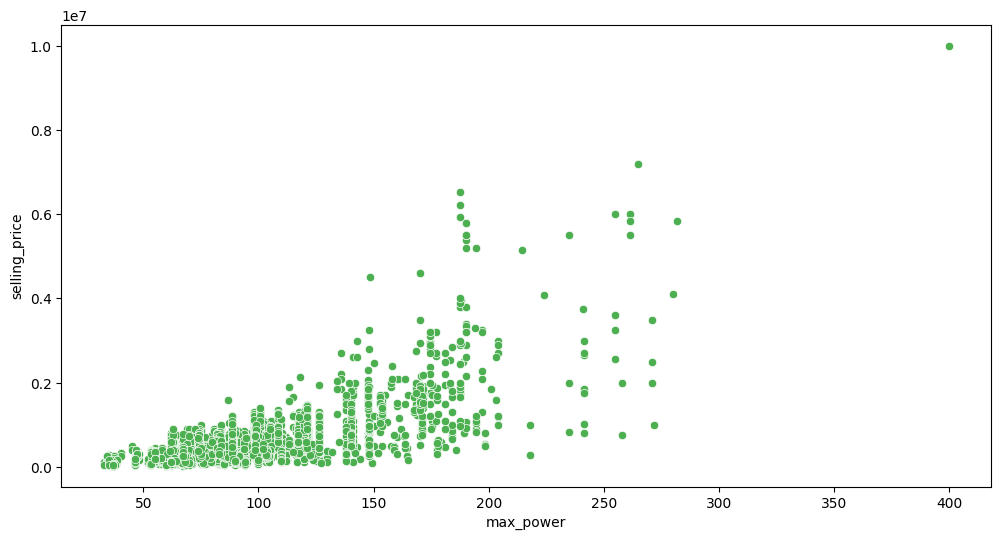

In [ ]:
# How do max_power and selling_price correlate? Is there a linear relationship between these two variables?

plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['max_power'], y=df['selling_price'],color = "#4CAF50")

<Axes: xlabel='fuel', ylabel='selling_price'>

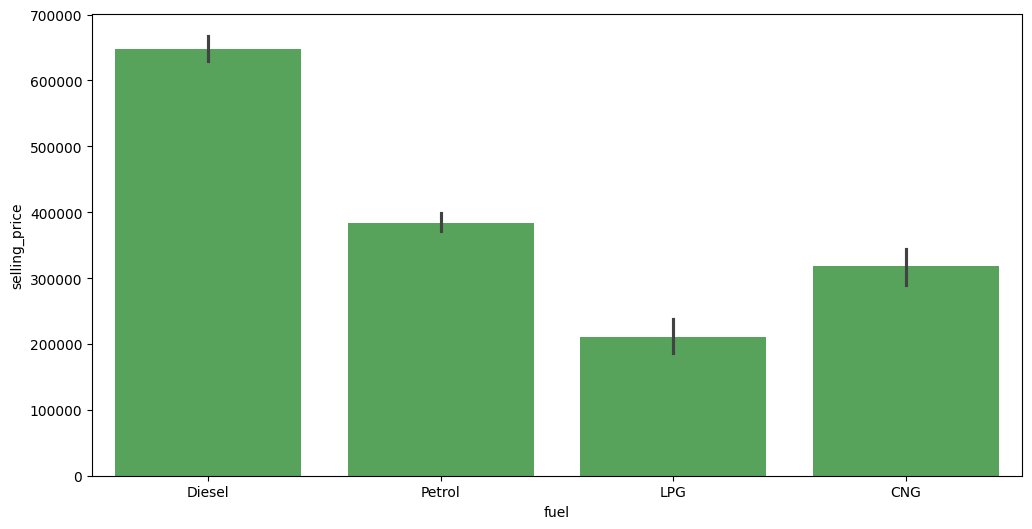

In [ ]:
# What is the difference in the distribution of selling_price across different fuel types?

plt.figure(figsize=(12, 6))
sns.barplot(x=df['fuel'], y=df['selling_price'],color = "#4CAF50")

<Axes: xlabel='transmission', ylabel='selling_price'>

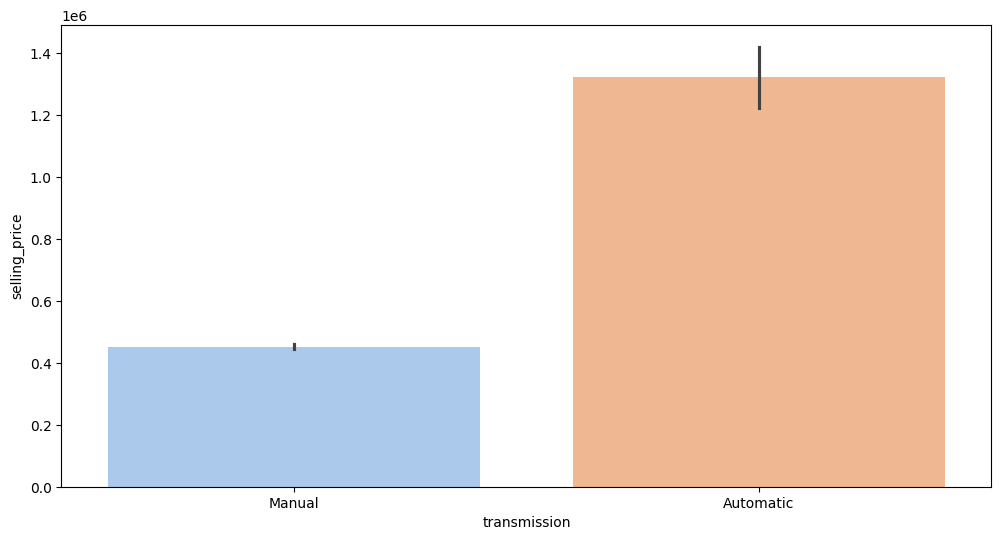

In [ ]:
# How does transmission type (Manual/Automatic) affect selling_price? Is there a significant difference?

plt.figure(figsize=(12, 6))
sns.barplot(x=df['transmission'], y=df['selling_price'],palette='pastel')

<Axes: xlabel='owner', ylabel='selling_price'>

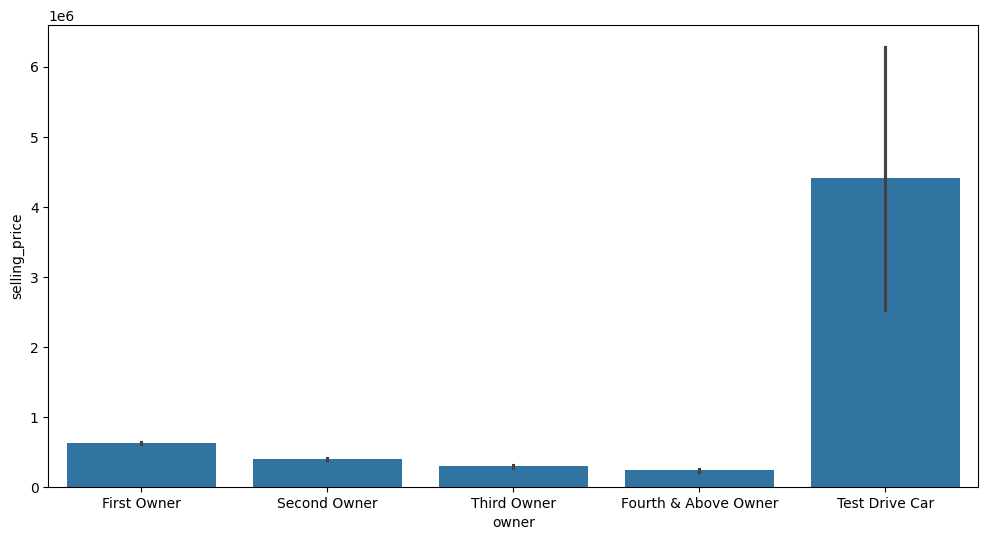

In [ ]:
# How does the number of owners affect selling_price?

plt.figure(figsize=(12, 6))
sns.barplot(x=df['owner'], y=df['selling_price'])

<Axes: xlabel='seller_type', ylabel='selling_price'>

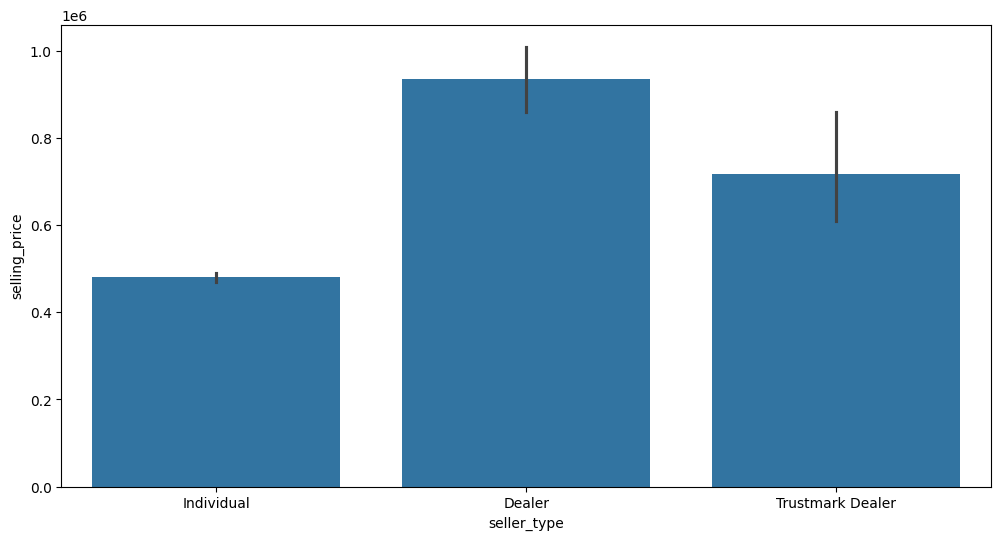

In [ ]:
# What is the relationship between seller_type (Individual vs. Dealer) and selling_price?

plt.figure(figsize=(12, 6))
sns.barplot(x=df['seller_type'], y=df['selling_price'])

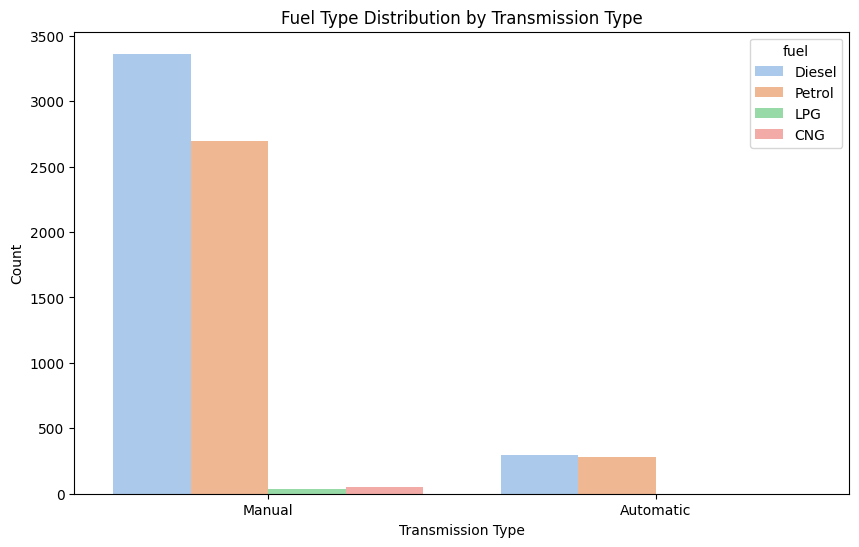

In [ ]:
# How does fuel type vary with transmission type?

plt.figure(figsize=(10, 6))
sns.countplot(x='transmission', hue='fuel', data=df, palette='pastel')
plt.title('Fuel Type Distribution by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Count')
plt.show()

<Axes: xlabel='seller_type', ylabel='count'>

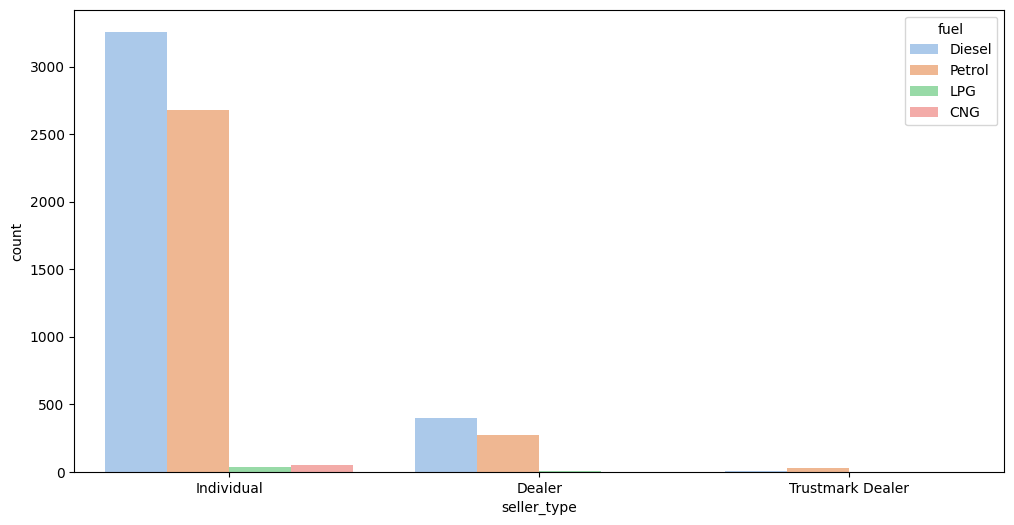

In [ ]:
# How do fuel and seller_type relate to each other?   Do Individual sellers tend to sell more Petrol cars than Diesel cars?)

plt.figure(figsize=(12, 6))
sns.countplot(x='seller_type', hue='fuel', data=df,palette='pastel')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, '1994'),
  Text(1, 0, '1995'),
  Text(2, 0, '1996'),
  Text(3, 0, '1997'),
  Text(4, 0, '1998'),
  Text(5, 0, '1999'),
  Text(6, 0, '2000'),
  Text(7, 0, '2001'),
  Text(8, 0, '2002'),
  Text(9, 0, '2003'),
  Text(10, 0, '2004'),
  Text(11, 0, '2005'),
  Text(12, 0, '2006'),
  Text(13, 0, '2007'),
  Text(14, 0, '2008'),
  Text(15, 0, '2009'),
  Text(16, 0, '2010'),
  Text(17, 0, '2011'),
  Text(18, 0, '2012'),
  Text(19, 0, '2013'),
  Text(20, 0, '2014'),
  Text(21, 0, '2015'),
  Text(22, 0, '2016'),
  Text(23, 0, '2017'),
  Text(24, 0, '2018'),
  Text(25, 0, '2019'),
  Text(26, 0, '2020')])

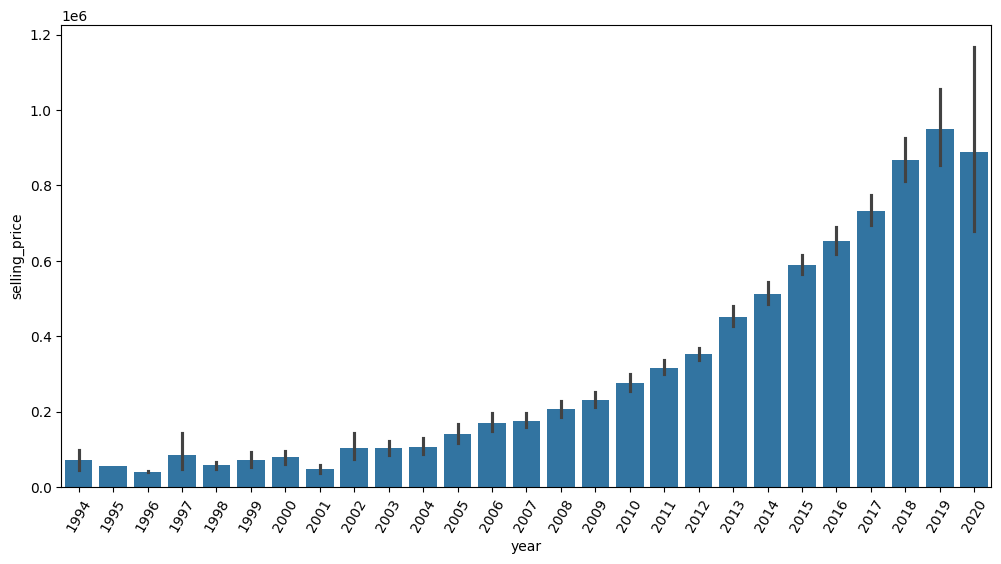

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x=df['year'], y=df['selling_price'])
plt.xticks(rotation=60)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26],
 [Text(0, 0, '1994'),
  Text(1, 0, '1995'),
  Text(2, 0, '1996'),
  Text(3, 0, '1997'),
  Text(4, 0, '1998'),
  Text(5, 0, '1999'),
  Text(6, 0, '2000'),
  Text(7, 0, '2001'),
  Text(8, 0, '2002'),
  Text(9, 0, '2003'),
  Text(10, 0, '2004'),
  Text(11, 0, '2005'),
  Text(12, 0, '2006'),
  Text(13, 0, '2007'),
  Text(14, 0, '2008'),
  Text(15, 0, '2009'),
  Text(16, 0, '2010'),
  Text(17, 0, '2011'),
  Text(18, 0, '2012'),
  Text(19, 0, '2013'),
  Text(20, 0, '2014'),
  Text(21, 0, '2015'),
  Text(22, 0, '2016'),
  Text(23, 0, '2017'),
  Text(24, 0, '2018'),
  Text(25, 0, '2019'),
  Text(26, 0, '2020')])

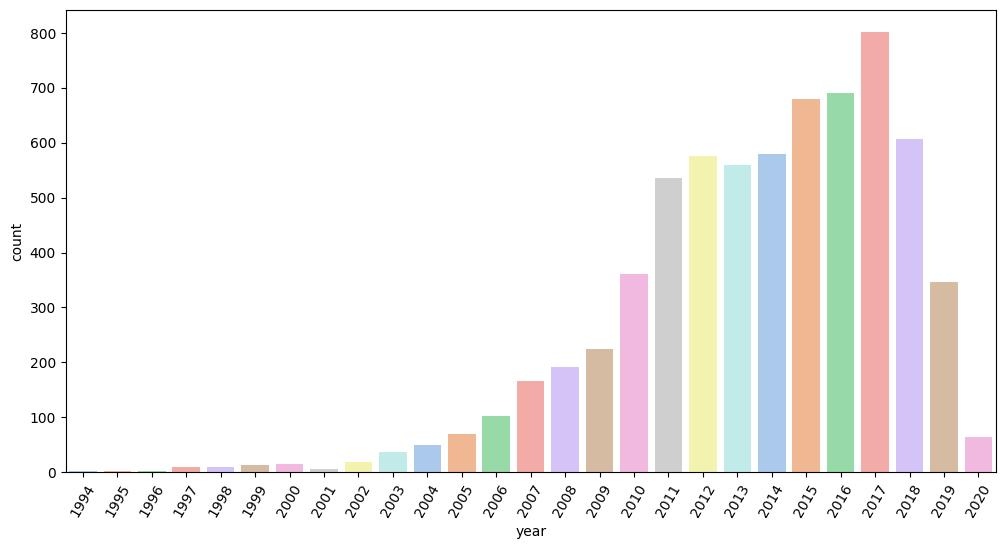

In [ ]:
# the top model make selling
plt.figure(figsize=(12, 6))

sns.countplot(x='year', data=df, palette='pastel')
plt.xticks(rotation=60)

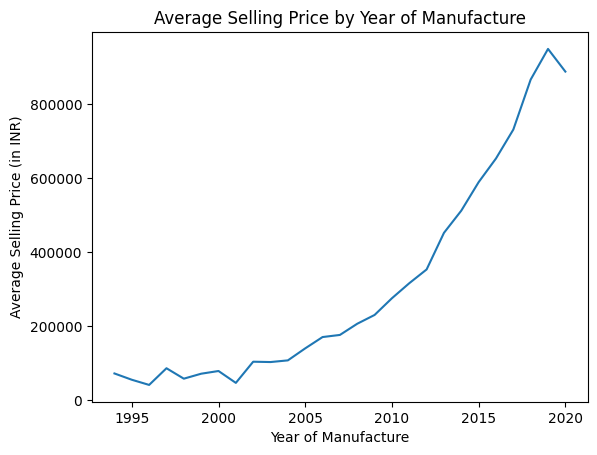

In [ ]:
df.groupby('year')['selling_price'].mean().plot(kind='line')
plt.title('Average Selling Price by Year of Manufacture')
plt.xlabel('Year of Manufacture')
plt.ylabel('Average Selling Price (in INR)')
plt.show()

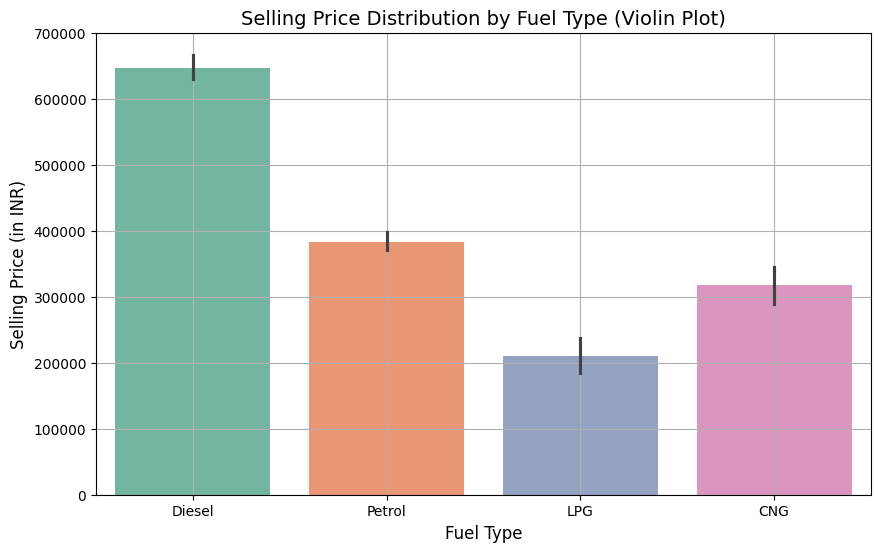

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='fuel', y='selling_price', data=df, palette='Set2')
plt.title('Selling Price Distribution by Fuel Type (Violin Plot)', fontsize=14)
plt.xlabel('Fuel Type', fontsize=12)
plt.ylabel('Selling Price (in INR)', fontsize=12)
plt.grid(True)
plt.show()

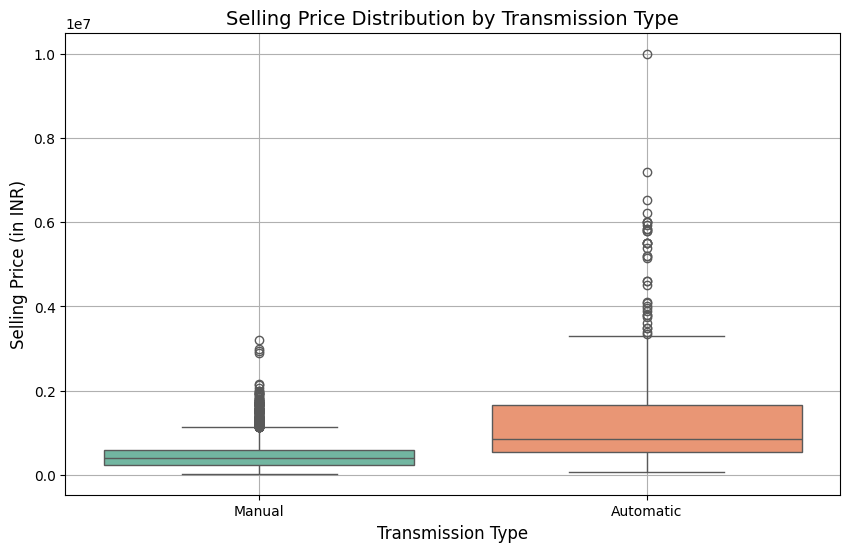

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='transmission', y='selling_price', data=df, palette='Set2')
plt.title('Selling Price Distribution by Transmission Type', fontsize=14)
plt.xlabel('Transmission Type', fontsize=12)
plt.ylabel('Selling Price (in INR)', fontsize=12)
plt.grid(True)
plt.show()

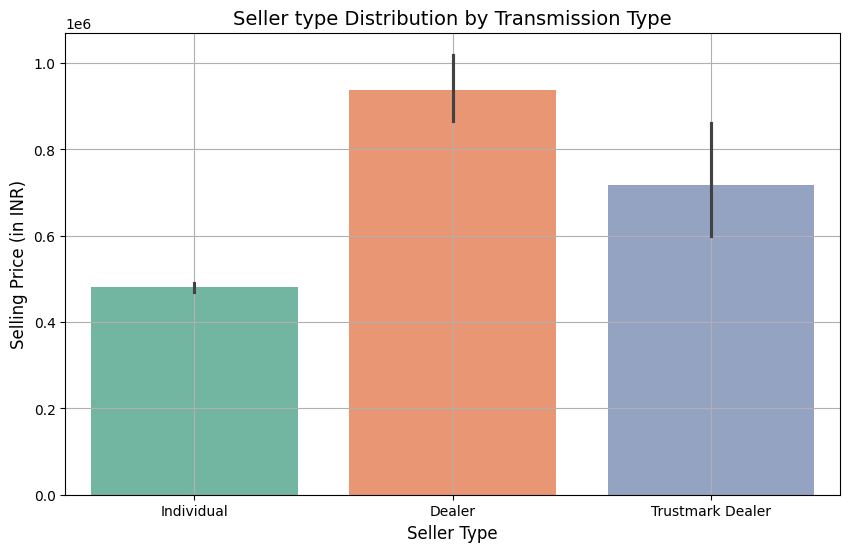

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='seller_type', y='selling_price', data=df, palette='Set2')
plt.title('Seller type Distribution by Transmission Type', fontsize=14)
plt.xlabel('Seller Type', fontsize=12)
plt.ylabel('Selling Price (in INR)', fontsize=12)
plt.grid(True)
plt.show()

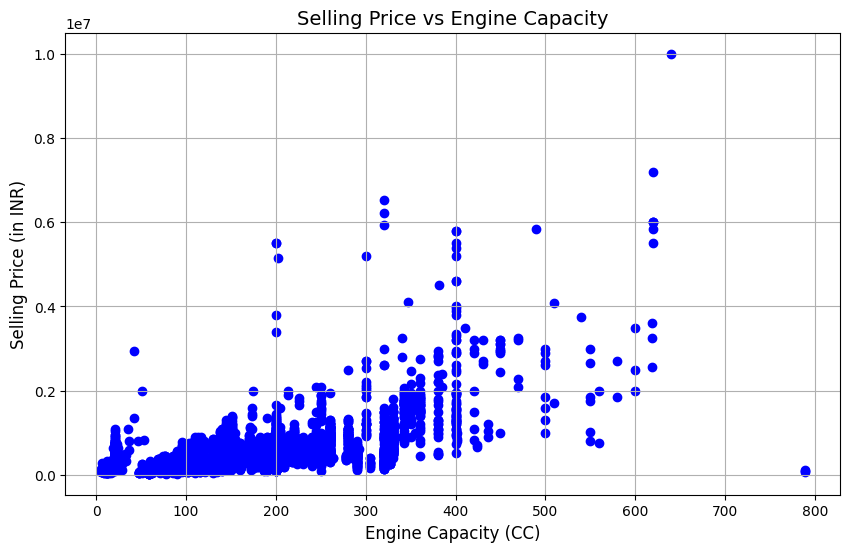

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Torque'], df['selling_price'], color='blue')
plt.title('Selling Price vs Engine Capacity', fontsize=14)
plt.xlabel('Engine Capacity (CC)', fontsize=12)
plt.ylabel('Selling Price (in INR)', fontsize=12)
plt.grid(True)
plt.show()

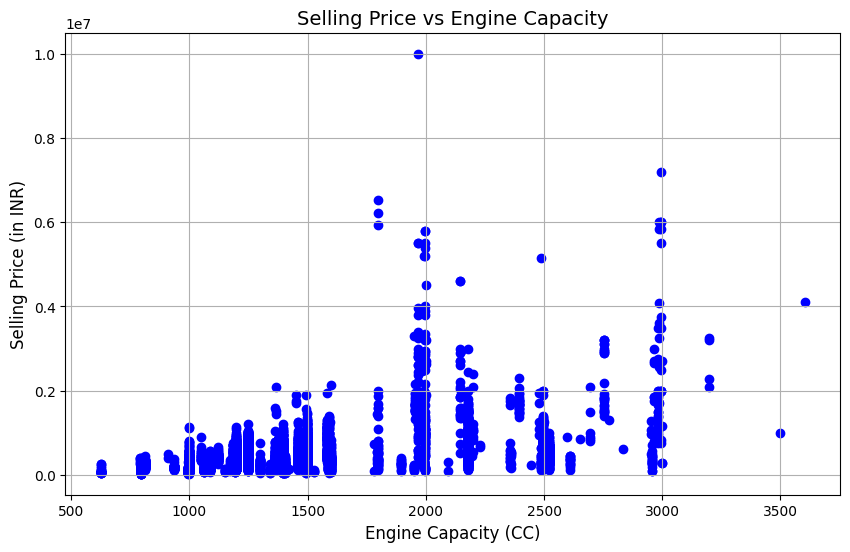

In [ ]:

# Scatter plot to see the relationship between engine capacity and selling price
plt.figure(figsize=(10, 6))
plt.scatter(df['engine'], df['selling_price'], color='blue')
plt.title('Selling Price vs Engine Capacity', fontsize=14)
plt.xlabel('Engine Capacity (CC)', fontsize=12)
plt.ylabel('Selling Price (in INR)', fontsize=12)
plt.grid(True)
plt.show()

<Axes: xlabel='owner'>

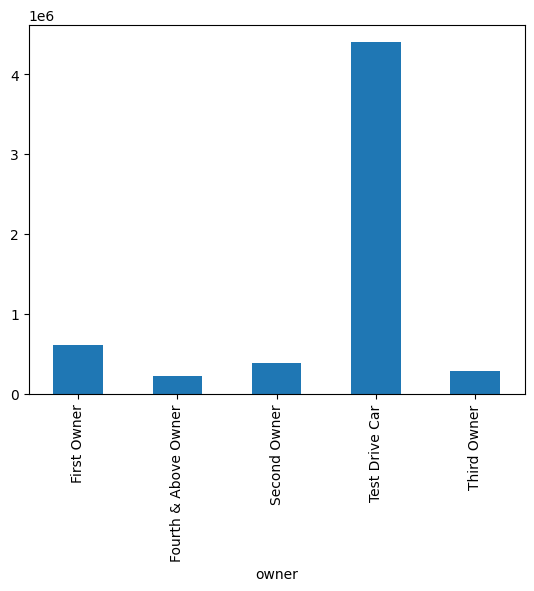

In [ ]:
df.groupby('owner')['selling_price'].mean().plot(kind='bar')

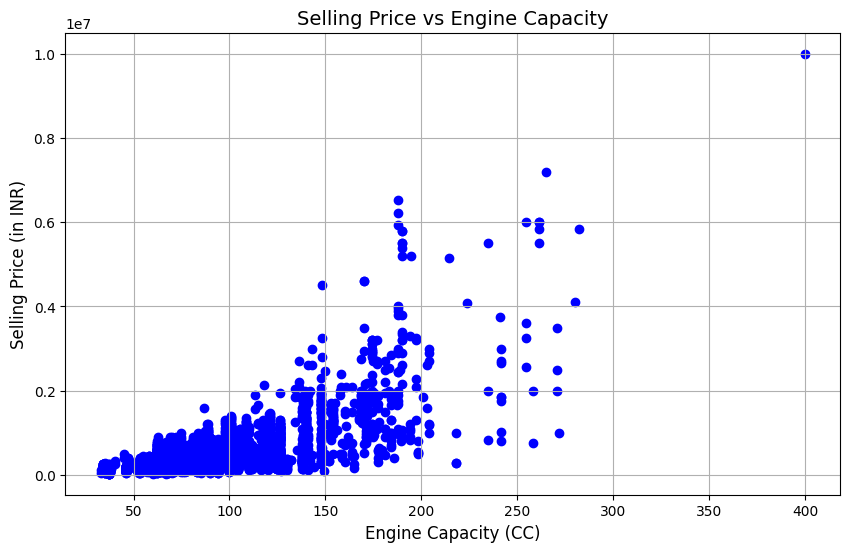

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['max_power'], df['selling_price'], color='blue')
plt.title('Selling Price vs Engine Capacity', fontsize=14)
plt.xlabel('Engine Capacity (CC)', fontsize=12)
plt.ylabel('Selling Price (in INR)', fontsize=12)
plt.grid(True)
plt.show()

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Torque
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,190.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,250.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,12.7
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,200.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,11.5


# **Feature Enginnering**

In [ ]:
le = LabelEncoder()

In [ ]:
df['fuel_encoded'] = le.fit_transform(df['fuel'])
df['seller_type_encoded'] = le.fit_transform(df['seller_type'])
df['transmission_encoded'] = le.fit_transform(df['transmission'])
df['owner_encoded'] = le.fit_transform(df['owner'])


In [ ]:
df[['fuel','fuel_encoded']].drop_duplicates()

,fuel,fuel_encoded
0,Diesel,1
2,Petrol,3
6,LPG,2
35,CNG,0


In [ ]:
df[['seller_type_encoded','seller_type']].drop_duplicates()

,seller_type_encoded,seller_type
0,1,Individual
42,0,Dealer
375,2,Trustmark Dealer


In [ ]:
df[['transmission_encoded','transmission']].drop_duplicates()

,transmission_encoded,transmission
0,1,Manual
41,0,Automatic


In [ ]:
df[['owner_encoded','owner']].drop_duplicates()

,owner_encoded,owner
0,0,First Owner
1,2,Second Owner
2,4,Third Owner
123,1,Fourth & Above Owner
4383,3,Test Drive Car


In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Torque,fuel_encoded,seller_type_encoded,transmission_encoded,owner_encoded
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,190.0,1,1,1,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,250.0,1,1,1,2
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,12.7,3,1,1,4
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,200.0,1,1,1,0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,11.5,3,1,1,0


In [ ]:
df.to_csv('cleaned_data.csv', index=False)


In [ ]:
X = df.drop(columns=['name','fuel','seller_type','transmission','owner','selling_price'])
y = df['selling_price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train

,year,km_driven,mileage,engine,max_power,seats,Torque,fuel_encoded,seller_type_encoded,transmission_encoded,owner_encoded
2583,2014,80000,19.10,1197.0,82.00,5.0,114.0,3,1,1,0
1428,2017,35000,25.83,1498.0,99.00,5.0,215.0,1,1,1,0
7288,2013,64000,14.62,1498.0,113.42,5.0,250.0,1,0,0,0
6851,2018,25000,28.40,1248.0,74.02,5.0,190.0,1,1,1,0
4447,2013,90000,22.90,1248.0,74.00,5.0,190.0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4475,2011,40000,20.92,998.0,67.10,5.0,90.0,3,1,1,2
6224,2015,80000,20.77,1248.0,88.80,7.0,200.0,1,1,1,0
6268,2019,14548,21.21,1197.0,81.80,5.0,113.0,3,0,1,0
6450,2014,100000,26.00,1498.0,98.60,5.0,200.0,1,1,1,2


In [ ]:
y

,selling_price
0,450000
1,370000
2,158000
3,225000
4,130000
...,...
8121,260000
8122,475000
8123,320000
8124,135000


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)


In [ ]:
X_test_scaled = scaler.fit_transform(X_test)

In [ ]:
X_train_scaled.shape

(5373, 11)

In [ ]:
X_train

,year,km_driven,mileage,engine,max_power,seats,Torque,fuel_encoded,seller_type_encoded,transmission_encoded,owner_encoded
2583,2014,80000,19.10,1197.0,82.00,5.0,114.0,3,1,1,0
1428,2017,35000,25.83,1498.0,99.00,5.0,215.0,1,1,1,0
7288,2013,64000,14.62,1498.0,113.42,5.0,250.0,1,0,0,0
6851,2018,25000,28.40,1248.0,74.02,5.0,190.0,1,1,1,0
4447,2013,90000,22.90,1248.0,74.00,5.0,190.0,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
4475,2011,40000,20.92,998.0,67.10,5.0,90.0,3,1,1,2
6224,2015,80000,20.77,1248.0,88.80,7.0,200.0,1,1,1,0
6268,2019,14548,21.21,1197.0,81.80,5.0,113.0,3,0,1,0
6450,2014,100000,26.00,1498.0,98.60,5.0,200.0,1,1,1,2


In [ ]:
y_train

,selling_price
2583,426999
1428,700000
7288,650000
6851,720000
4447,409999
...,...
4475,229999
6224,650000
6268,595000
6450,560000


In [ ]:
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))

In [ ]:
y_test_scaled = target_scaler.fit_transform(y_test.values.reshape(-1, 1))

In [ ]:
y_train_scaled

array([[-0.19322597],
       [ 0.31579939],
       [ 0.22257164],
       ...,
       [ 0.12002112],
       [ 0.0547617 ],
       [-0.46731368]])

In [ ]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(target_scaler, 'target_scaler.pkl')

['target_scaler.pkl']

# **Building Model**

In [ ]:
lr = LinearRegression()
rfr = RandomForestRegressor()
xgr = XGBRegressor()
svr = SVR()
nr = KNeighborsRegressor()
ent = ElasticNet()


In [ ]:
param1 = {}
param1['regression'] = [lr]

param2 = {}
param2['regression__n_estimators'] = [100, 200, 300]
param2['regression__max_depth'] = [None, 10, 20, 30]
param2['regression__min_samples_split'] = [2, 5, 10]
param2['regression__min_samples_leaf'] = [1, 2, 4]
param2['regression__max_features'] = ['auto', 'sqrt', 'log2']
param2['regression__random_state'] = [42]
param2['regression'] = [rfr]

param3 = {}
param3['regression__n_estimators'] = [100, 200, 300]
param3['regression__learning_rate'] = [0.01, 0.1, 0.2]
param3['regression__max_depth'] = [3, 5, 7]
param3['regression__subsample'] = [0.8, 0.9, 1.0]
param3['regression__colsample_bytree'] = [0.8, 0.9, 1.0]
param3['regression__gamma'] = [0, 0.1, 0.2]
param3['regression__random_state'] = [42]
param3['regression'] = [xgr]

param4 = {}
param4['regression__C'] = [0.1, 1, 10]
param4['regression__kernel'] = ['linear', 'rbf', 'poly']
param4['regression__degree'] = [3, 5]  # Only for 'poly' kernel
param4['regression__gamma'] = ['scale', 'auto']
param4['regression__epsilon'] = [0.1, 0.2]
param4['regression'] = [svr]

param5 = {}
param5['regression__n_neighbors'] = [3, 5, 10]
param5['regression__weights'] = ['uniform', 'distance']
param5['regression__algorithm'] = ['auto', 'ball_tree', 'kd_tree', 'brute']
param5['regression__leaf_size'] = [30, 40, 50]
param5['regression'] = [nr]

param6 = {}
param6['regression__alpha'] = [0.01, 0.1, 1, 10]
param6['regression__l1_ratio'] = [0.1, 0.5, 0.9]
param6['regression__max_iter'] = [1000, 2000]
param6['regression__fit_intercept'] = [True, False]
param6['regression'] = [ent]

In [ ]:
pipline  = Pipeline([('regression',lr)])
params = [param1,param2,param3,param4,param5,param6]

In [ ]:
grid = GridSearchCV(pipline,params,cv=5,n_jobs=-1,verbose=1)

In [ ]:
start_time = time.time()

In [ ]:
grid.fit(X_train_scaled,y_train_scaled)

Fitting 5 folds for each of 1246 candidates, totalling 6230 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('regression', LinearRegression())]),
             n_jobs=-1,
             param_grid=[{'regression': [LinearRegression()]},
                         {'regression': [RandomForestRegressor()],
                          'regression__max_depth': [None, 10, 20, 30],
                          'regression__max_features': ['auto', 'sqrt', 'log2'],
                          'regression__min_samples_leaf': [1, 2, 4],
                          'regression__min_samples_split': [2, 5, 10],
                          'r...
                          'regression__algorithm': ['auto', 'ball_tree',
                                                    'kd_tree', 'brute'],
                          'regression__leaf_size': [30, 40, 50],
                          'regression__n_neighbors': [3, 5, 10],
                          'regression__weights': ['uniform', 'distance']},
                         {'regression': [ElasticNet()],
                          'regression__alpha': [0.01, 0.1, 1, 10],
                          'regression__fit_intercept': [True, False],
                          'regression__l1_ratio': [0.1, 0.5, 0.9],
                          'regression__max_iter': [1000, 2000]}],
             verbose=1)

In [ ]:
end_time = time.time()

In [ ]:
time_taken = end_time - start_time

In [ ]:
print(f"Time taken to fit the model: {time_taken} seconds")

Time taken to fit the model: 3977.9008083343506 seconds


In [ ]:
print(time_taken / 60)

66.2983468055725


# **Evaluating Model**

In [ ]:
grid.best_params_

{'regression': RandomForestRegressor(),
 'regression__max_depth': 20,
 'regression__max_features': 'sqrt',
 'regression__min_samples_leaf': 1,
 'regression__min_samples_split': 2,
 'regression__n_estimators': 300,
 'regression__random_state': 42}

In [ ]:
grid.best_score_

0.8866796946137849

In [ ]:
model = grid.best_estimator_

In [ ]:
y_pre = model.predict(X_test_scaled)

In [ ]:
r2_score(y_test_scaled,y_pre)

0.9045065227003625

In [ ]:
mean_squared_error(y_test_scaled,y_pre)

0.0954934772996375

In [ ]:
mean_absolute_error(y_test_scaled,y_pre)

0.1889065106104101

In [ ]:
USER = np.array([[2014,80000,19.10,1197.0,82.00,5.0,114.0,3,1,1,0	]])

In [ ]:
g = scaler.transform(USER)

In [ ]:
pre = model.predict(g)

In [ ]:
target_scaler.inverse_transform(pre.reshape(-1, 1))

array([[388527.68339761]])

In [ ]:
joblib.dump(model,'model.pkl')

['model.pkl']

In [ ]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats,Torque,fuel_encoded,seller_type_encoded,transmission_encoded,owner_encoded
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74.00,5.0,190.0,1,1,1,0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0,250.0,1,1,1,2
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78.00,5.0,12.7,3,1,1,4
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90.00,5.0,200.0,1,1,1,0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.20,5.0,11.5,3,1,1,0
